# Analysis of Global Climate Anomalies

## Objective

In this notebook, we analyze monthly global temperature anomalies using the NASA GISTEMP v4 dataset.

The analysis includes:

- loading and cleaning the data;
- visualizing the time series;
- constructing temporal and autoregressive features;
- estimating the climate trend;
- forecasting future anomalies;
- comparing machine learning models.

## Dataset

The dataset contains monthly global land–ocean temperature anomalies, expressed in °C relative to the 1951–1980 reference climatology.

## Data Preparation

The data are transformed into long format and sorted chronologically. For each observation, we retain:

- year;
- month;
- temperature anomaly;
- monthly date.

## Feature Engineering

From the time series, we construct:

- `t_years`: time elapsed since the start of the series, in years;
- `sin_month` and `cos_month`: cyclic encoding of seasonality;
- `lag_1` through `lag_12`: anomalies from the previous twelve months.

The lags allow the models to use the recent memory of the time series.

## Interpretable Model

Linear regression estimates the anomaly as a function of the temporal trend and seasonality.

The coefficient associated with `t_years` represents the estimated trend in °C/year. The same value is also reported in °C/century.

## Predictive Models

We compare two models:

- polynomial regression of degree 2;
- random forest regression.

The data are split chronologically: the earlier portion is used for training, while the more recent period is reserved for evaluation.

## Metrics

Performance is evaluated using:

- **MAE**: mean absolute error;
- **RMSE**: root mean squared error;
- **R**: proportion of variability explained by the model.

## Interpretation

For the random forest, we also compute permutation importance, which measures how much the prediction worsens when a feature is permuted.

The most important features indicate which temporal information contributes most to forecasting the anomalies.

## Conclusions

The results should be interpreted by distinguishing between:

- statistical description of the observed trend;
- predictive performance on recent data;
- feature importance;
- limitations due to the temporal and non-stationary nature of climate.

Good predictive performance does not necessarily imply a causal relationship.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Directory kernel:", Path.cwd())
print("Project root:", project_root)

Directory kernel: /Users/anvi/Desktop/climate_science/notebook
Project root: /Users/anvi/Desktop/climate_science


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from funcs.climate_funcs import (
    load_gistemp,
    make_features,
    fit_inference_model,
    fit_prediction_models,
)

We want to study the function:

$Y_t = f(X_t) + \epsilon_t$

In [5]:
climate = load_gistemp()
climate.head()

,year,month_name,anomaly,month,date
0,1880,Jan,-0.19,1,1880-01-01
1,1880,Feb,-0.26,2,1880-02-01
2,1880,Mar,-0.10,3,1880-03-01
3,1880,Apr,-0.17,4,1880-04-01
4,1880,May,-0.11,5,1880-05-01


In [6]:
climate_ml = make_features(
    climate,
    n_lags=12,
)
climate_ml.head()

,year,month_name,anomaly,month,date,t_years,sin_month,cos_month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
0,1881,Jan,-0.20,1,1881-01-01,1.002074,0.500000,8.660254e-01,-0.18,-0.23,-0.24,-0.15,-0.11,-0.19,-0.22,-0.11,-0.17,-0.10,-0.26,-0.19
1,1881,Feb,-0.15,2,1881-02-01,1.086949,0.866025,5.000000e-01,-0.20,-0.18,-0.23,-0.24,-0.15,-0.11,-0.19,-0.22,-0.11,-0.17,-0.10,-0.26
2,1881,Mar,0.03,3,1881-03-01,1.163610,1.000000,6.123234e-17,-0.15,-0.20,-0.18,-0.23,-0.24,-0.15,-0.11,-0.19,-0.22,-0.11,-0.17,-0.10
3,1881,Apr,0.05,4,1881-04-01,1.248486,0.866025,-5.000000e-01,0.03,-0.15,-0.20,-0.18,-0.23,-0.24,-0.15,-0.11,-0.19,-0.22,-0.11,-0.17
4,1881,May,0.05,5,1881-05-01,1.330623,0.500000,-8.660254e-01,0.05,0.03,-0.15,-0.20,-0.18,-0.23,-0.24,-0.15,-0.11,-0.19,-0.22,-0.11


In [7]:
inference = fit_inference_model(climate_ml)

print(f"Estimated trend: "f"{inference['trend_degC_per_year']:.5f} °C/anno")
print(f"Estimated trend: "f"{inference['trend_degC_per_century']:.3f} °C/secolo")
print(f"R²: {inference['r2']:.3f}")
print(f"Standard deviation of residuals ε: "f"{inference['residual_std_degC']:.3f} °C")

Estimated trend: 0.00853 °C/anno
Estimated trend: 0.853 °C/secolo
R²: 0.722
Standard deviation of residuals ε: 0.223 °C


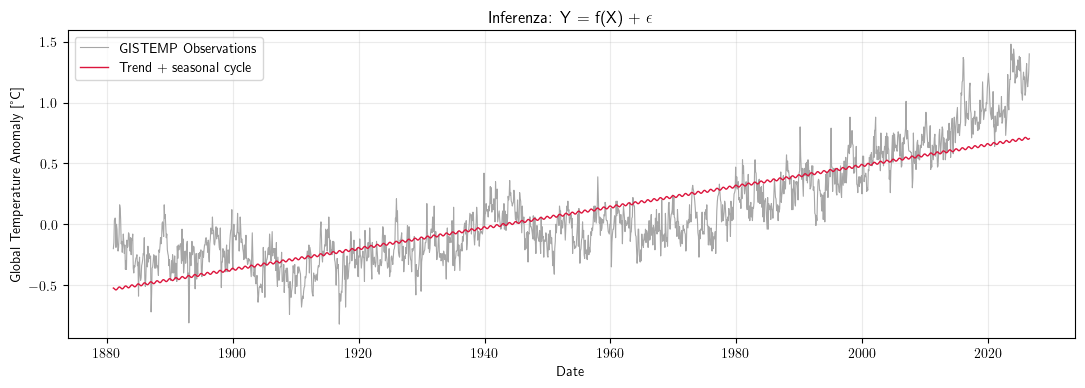

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    inference["data"]["date"],
    inference["data"]["anomaly"],
    color="0.65", linewidth=0.8, label="GISTEMP Observations",
)

ax.plot(
    inference["data"]["date"],
    inference["fitted"],
    color="crimson", linewidth=1.0, label="Trend + seasonal cycle",
)
ax.plot(dpi = 300)


ax.set_xlabel("Date")
ax.set_ylabel("Global Temperature Anomaly [°C]")
ax.set_title(r"Inferenza: Y = f(X) + $\epsilon$")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

In [9]:
prediction = fit_prediction_models(
    climate_ml,
    train_fraction=0.80,
    random_state=42,
)

prediction["metrics"]

,MAE_degC,RMSE_degC,R2
polynomial,0.099762,0.124320,0.773929
random_forest,0.368583,0.443132,-1.872285


In [10]:
prediction["random_forest_importance"].head(10)

lag_1      3.455584e-02
month      1.262613e-02
lag_2      5.316385e-03
lag_3      3.799061e-03
lag_7      1.933523e-03
lag_9      1.785353e-03
lag_4      7.010275e-04
t_years    3.552714e-16
lag_8     -4.012201e-04
lag_5     -1.175132e-03
Name: permutation_importance, dtype: float64

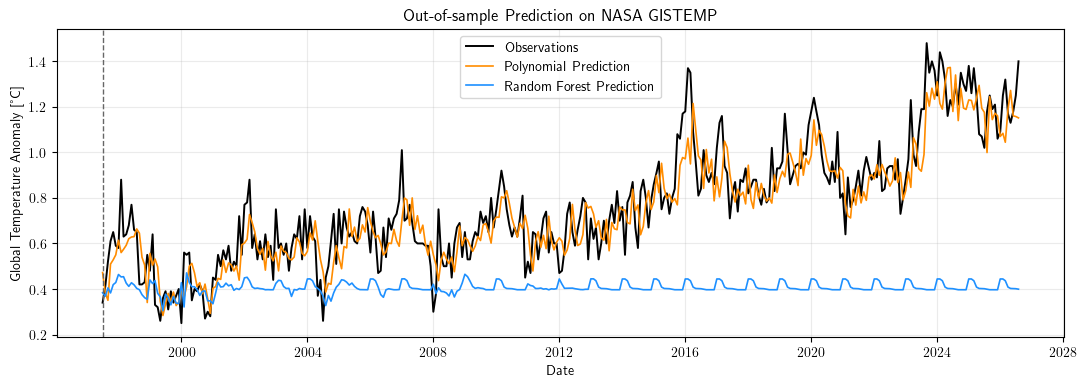

In [11]:
test = prediction["test"]

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    test["date"],
    test["anomaly"],
    color="black",
    linewidth=1.4,
    label="Observations",
)

ax.plot(
    test["date"],
    prediction["predictions"]["polynomial"],
    color="darkorange",
    linewidth=1.2,
    label="Polynomial Prediction",
)

ax.plot(
    test["date"],
    prediction["predictions"]["random_forest"],
    color="dodgerblue",
    linewidth=1.2,
    label="Random Forest Prediction",
)

ax.axvline(
    test["date"].iloc[0],
    color="0.4",
    linestyle="--",
    linewidth=1.0,
)

ax.plot(dpi = 1000)

ax.set_xlabel("Date")
ax.set_ylabel("Global Temperature Anomaly [°C]")
ax.set_title("Out-of-sample Prediction on NASA GISTEMP")
ax.grid(alpha=0.25)
ax.legend()

plt.show()
